In this notebook, you should use the equations and general recipe covered in the lecture to perform logistic regression on part of the MNIST dataset. When in doubt, looking at the slides may help your memory ;)

In [1]:
#load packages
import numpy as np
import sklearn.model_selection
import matplotlib.pyplot as plt


In [2]:
#make helper functions

def plot_digit(X, y, idx):
    img = X[idx].reshape(28,28)
    plt.imshow(img, cmap='Greys',  interpolation='nearest')
    plt.title('true label: %d' % y[idx])
    plt.show()


In [3]:
#load data

from mlxtend.data import mnist_data
X, y = mnist_data()


#we just focus on 1's and 0's:
keep=(y==0) | (y==1)
X=X[keep,:]
y=y[keep]

y=np.expand_dims(y,1)

In [4]:
#inspect data

# (plot digit)


In [5]:
# create a (binary cross entropy) loss function as discussed in the slides:
def avrLoss(y,a):           #page59 in week1's slides     Binary cross-entropy function

  #INSERT CODE
  epsilon = 1e-15  # small value to avoid log(0)
  a = np.clip(a, epsilon, 1 - epsilon)  # clip to be safe right??
  loss = - (y * np.log(a) + (1 - y) * np.log(1 - a))  # binary cross-entropy loss from slides (super simple networks)
  return np.mean(loss)

In [6]:
#test loss function:
#(just run this cell and see what happens)


loss=avrLoss(np.array([0,1,0,1]),np.linspace(.1,.9,4))
assert np.all(loss==0.5543313122608056)

In [7]:
#create a sigmoid          page 58
def sigmoid(z):
  #INSERT CODE
  return 1/(1 + np.exp(-z))

In [8]:
#check sigmoid
#(just run this cell and see what happens)

out=sigmoid(np.array(range(-5,5)))
assert np.all(np.around(out,8)==np.array([0.00669285, 0.01798621, 0.04742587, 0.11920292, 0.26894142, 0.5, 0.73105858, 0.88079708, 0.95257413, 0.98201379]))

In [9]:
#make test & train data

Xtrain,Xtest,ytrain,ytest=sklearn.model_selection.train_test_split(X,y,test_size=0.3,shuffle=True)

In [10]:
#train
np.random.seed(117)
#INITIATE WEIGHTS AND BIASES (w,b)
w=np.random.random((Xtrain.shape[1],1))      #random
b=np.random.random((1,1))     #random

nEpoch= 1000   #random

accuracy=np.zeros(nEpoch)
trainRate=0.01  #pick a number less than 1

for iTrain in range(nEpoch):
	#evaluate
	#CALCULATE a
	a = sigmoid(np.matmul(Xtrain,w)+b)

	#calculate loss & accuracy
	loss=avrLoss(ytrain,a)      #use the function you defined

	yhat=a>.5
	accuracy[iTrain]=np.mean(yhat==ytrain)


	#update weights       page62      the same page with 'UPDATE W AND b'
	m = Xtrain.shape[0]
	wgrad = (1/m) * np.matmul(Xtrain.T, (a - ytrain)) #matmul is what help cast size correctly, from slides page 65
	bgrad = np.mean(a - ytrain)

	#formulas are in page 65,and a is calculated from sigmoid ; y is ytrain;
	#                           and x is the data or images you loaded



	assert(wgrad.shape == w.shape)

	#UPDATE W AND b
	#this was int he slides too
	w = w - trainRate * wgrad
	b = b - trainRate * bgrad
  
 #Notes: the 'some sensible step size' mentioned in page62 is just the trainRate

	if np.mod(iTrain,10)==0:
		print(iTrain,loss,accuracy[iTrain])

Y_prediction_test = sigmoid(np.matmul(Xtest,w)+b)>0.5
Y_prediction_train = sigmoid(np.matmul(Xtrain,w)+b)>0.5

print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - ytrain)) * 100))
print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - ytest)) * 100))

0 17.171103493335178 0.5028571428571429
10 0.12438871804541947 0.9957142857142857


/tmp/ipykernel_14552/268794605.py:4: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


20 0.049341109135587674 0.9985714285714286
30 0.11593612678218863 0.9942857142857143
40 0.04934110913558771 0.9985714285714286
50 0.004642265731040627 0.9985714285714286
60 9.992007221626413e-16 1.0
70 9.992007221626413e-16 1.0
80 9.992007221626413e-16 1.0
90 9.992007221626413e-16 1.0
100 9.992007221626413e-16 1.0
110 9.992007221626413e-16 1.0
120 9.992007221626413e-16 1.0
130 9.992007221626413e-16 1.0
140 9.992007221626413e-16 1.0
150 9.992007221626413e-16 1.0
160 9.992007221626413e-16 1.0
170 9.992007221626413e-16 1.0
180 9.992007221626413e-16 1.0
190 9.992007221626413e-16 1.0
200 9.992007221626413e-16 1.0
210 9.992007221626413e-16 1.0
220 9.992007221626413e-16 1.0
230 9.992007221626413e-16 1.0
240 9.992007221626413e-16 1.0
250 9.992007221626413e-16 1.0
260 9.992007221626413e-16 1.0
270 9.992007221626413e-16 1.0
280 9.992007221626413e-16 1.0
290 9.992007221626413e-16 1.0
300 9.992007221626413e-16 1.0
310 9.992007221626413e-16 1.0
320 9.992007221626413e-16 1.0
330 9.992007221626413e-1

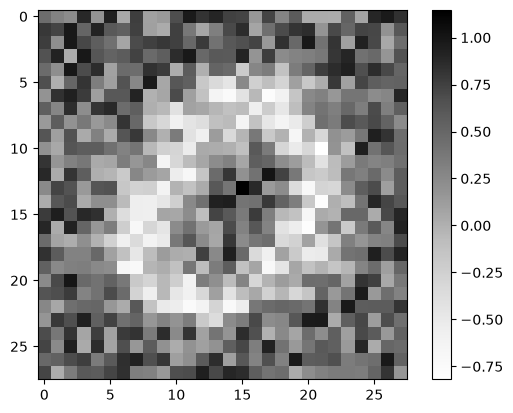

In [11]:
#see what the network does:

img = w.reshape(28,28)
h=plt.imshow(img, cmap='Greys',  interpolation='nearest')
plt.colorbar(h)
plt.show()

/home/stefan_stringer/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Train accuracy:  1.0
Test accuracy:  0.9966666666666667


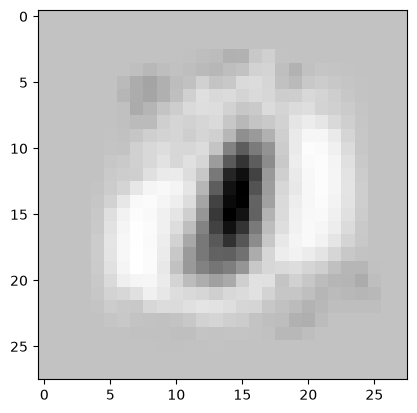

In [12]:
#commpare with scikit-learn:

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0).fit(Xtrain, ytrain)

clf.predict(X)
print('Train accuracy: ',clf.score(Xtrain, ytrain))
print('Test accuracy: ',clf.score(Xtest, ytest))

img = (clf.coef_).reshape(28,28)
plt.imshow(img, cmap='Greys',  interpolation='nearest')
plt.show()